In [79]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time
from copy import copy
from skimage.filters import gaussian
import xarray as xr

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

from src import AnalysisFunctions

AF = AnalysisFunctions.Analysis_Functions()

import colour

from colour_demosaicing import (
    ROOT_RESOURCES_EXAMPLES,
    demosaicing_CFA_Bayer_bilinear,
    demosaicing_CFA_Bayer_Malvar2004,
    demosaicing_CFA_Bayer_Menon2007,
    mosaicing_CFA_Bayer,
)

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

In [80]:
data_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

image_size = 26

from Camera_QE import getpixelefficiency

gpe = getpixelefficiency.GPE()
R, G, B, wavelength = gpe.getpixelefficiency("Camera_QE/CS505CU_QE.csv")
masks = MSF.MF.get_masks(MSF.mosaic_unit, image_size, image_size)
masks_3d = np.dstack([masks["maskR"], masks["maskG"], masks["maskB"]])
wavelength = wavelength
absolute_QYs = np.vstack([B, G, R])
camera_calibration = {}
camera_calibration["gain"] = gain[:image_size, :image_size]
camera_calibration["offset"] = offset[:image_size, :image_size]
camera_calibration["variance"] = variance[:image_size, :image_size]
camera_calibration["readnoise"] = readnoise[:image_size, :image_size]
camera_calibration["rqe"] = rqe[:image_size, :image_size]

In [81]:
folder = "Spectra/Em/Dyes/"
emission_spectra = np.sort(os.listdir(folder))
ATTO550_name = emission_spectra[28]
ATTO647N_name = emission_spectra[36]

dye_names = np.array([ATTO550_name, ATTO647N_name])

In [82]:
n_photon = 4000
background_photons = 0
pixel_scan = 10
pixel_size_lspace = np.arange(20, 200 + pixel_scan, pixel_scan)
NA = 1.49

In [83]:
n_photons = {}
n_photons["dye"] = n_photon

In [86]:
saving_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241113/data"

dyes = np.zeros([1, len(wavelength)])

separator = "\t"
skip_rows = 1

for dye in dye_names:
    name = dye.split("_")[0]
    data = pl.read_csv(
        os.path.join(folder, dye), separator=separator, skip_rows=skip_rows
    )
    d_wl = data[:, 0].to_numpy()
    d_em = data[:, 1].to_numpy()
    ATTO550 = np.interp(x=wavelength, xp=d_wl, fp=d_em)
    ATTO550 = ATTO550 / np.sum(ATTO550)
    dyes[0, :] = ATTO550

    average_emission_wavelength = np.trapz(
        y=wavelength * (dyes.T / np.trapz(x=wavelength, y=dyes)).T, x=wavelength
    )
    sigma_PSF = PSF.sigma_PSF(float(average_emission_wavelength[0]), NA)
    dye_pixel_efficiency = np.dot(dyes, absolute_QYs.T)

    for pixel_size in pixel_size_lspace:
        max = pixel_size * image_size
        x0y0 = {}
        x0y0["dye"] = np.array([[max / 2], [max / 2]])

        ground_truth, bayer_image = MSF.gen_camera_images(
            camera_calibration,
            wavelength,
            absolute_QYs,
            dyes,
            n_photons,
            x0y0,
            background_photons=background_photons,
            NA=NA,
            pixel_size=pixel_size,
        )

        fig, axs = plotter.one_column_plot()

        axs = plotter.image_plot(
            axs=axs,
            data=bayer_image,
            pixelsize=pixel_size,
            scalebarsize=300,
            scalebarlabel="300 nm",
            cbarlabel="intensity",
        )

        plt.savefig(
            os.path.join(
                saving_folder,
                "example_simulation_dye_"
                + str(name)
                + "_pixelsize_"
                + str(int(pixel_size))
                + "nm.svg",
            ),
            format="svg",
            dpi=600,
        )
        plt.close("all")

        IO.write_tiff(
            bayer_image,
            os.path.join(
                saving_folder,
                "example_simulation_dye_"
                + str(name)
                + "_pixelsize_"
                + str(int(pixel_size))
                + "nm.tif",
            ),
        )

In [2]:
import polars as pl

In [99]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241030/data"
fittesting_ATTO390_VU_RN = pl.read_csv(
    os.path.join(
        folder, "ATTO390_pixelsizetesting_nphoton_4000_RMSE_mean_VUxyestimation.csv"
    )
)
fittesting_ATTO488_VU_RN = pl.read_csv(
    os.path.join(
        folder, "ATTO488_pixelsizetesting_nphoton_4000_RMSE_mean_VUxyestimation.csv"
    )
)
fittesting_ATTO550_VU_RN = pl.read_csv(
    os.path.join(
        folder, "ATTO550_pixelsizetesting_nphoton_4000_RMSE_mean_VUxyestimation.csv"
    )
)
fittesting_ATTO647N_VU_RN = pl.read_csv(
    os.path.join(
        folder, "ATTO647N_pixelsizetesting_nphoton_4000_RMSE_mean_VUxyestimation.csv"
    )
)
fittesting_ATTO740_VU_RN = pl.read_csv(
    os.path.join(
        folder, "ATTO740_pixelsizetesting_nphoton_4000_RMSE_mean_VUxyestimation.csv"
    )
)

fittest_VU_RN = (
    fittesting_ATTO390_VU_RN
    + fittesting_ATTO488_VU_RN
    + fittesting_ATTO550_VU_RN
    + fittesting_ATTO647N_VU_RN
    + fittesting_ATTO740_VU_RN
) / 5

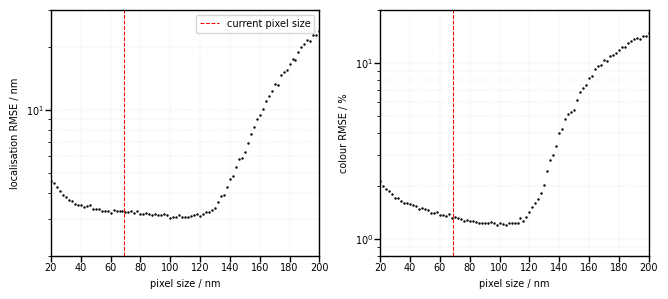

In [110]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

axs[0] = plotter.scatter_plot(
    axs=axs[0],
    x=fittest_VU_RN["pixel_size"].to_numpy(),
    y=0.5 * (fittest_VU_RN["xc"].to_numpy() + fittest_VU_RN["yc"].to_numpy()),
    xaxislabel="pixel size / nm",
    yaxislabel="localisation RMSE / nm",
    edgecolor="k",
    s=1,
)

axs[1] = plotter.scatter_plot(
    axs=axs[1],
    x=fittest_VU_RN["pixel_size"].to_numpy(),
    y=(100.0 / 3)
    * (
        fittest_VU_RN["R"].to_numpy()
        + fittest_VU_RN["G"].to_numpy()
        + fittest_VU_RN["B"].to_numpy()
    ),
    xaxislabel="pixel size / nm",
    yaxislabel="colour RMSE / %",
    edgecolor="k",
    s=1,
)


axs[0].vlines(
    x=69, ymin=0, ymax=100, ls="--", color="red", lw=0.75, label="current pixel size"
)
axs[0].legend(loc="best")
axs[0].set_ylim([2, 30])
axs[0].set_yscale("log")

axs[1].vlines(
    x=69, ymin=0, ymax=100, ls="--", color="red", lw=0.75, label="current pixel size"
)
axs[1].set_ylim([0.8, 20])
axs[1].set_yscale("log")
plt.tight_layout()

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20241114/fig/multicolour_camera/algorithm"

plt.savefig(os.path.join(savefolder, "Pixel_Size_Testing.svg"), format="svg", dpi=600)
plt.show()

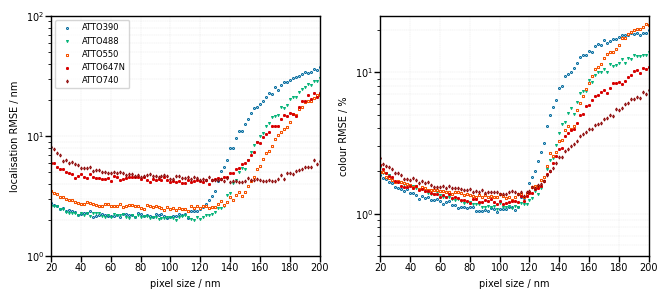

In [118]:
overall_fit_array = [
    fittesting_ATTO390_VU_RN,
    fittesting_ATTO488_VU_RN,
    fittesting_ATTO550_VU_RN,
    fittesting_ATTO647N_VU_RN,
    fittesting_ATTO740_VU_RN,
]
cs = ["#006a9e", "#00b276", "#f55200", "#d80000", "#8b0000"]
string_array = ["ATTO390", "ATTO488", "ATTO550", "ATTO647N", "ATTO740"]
point_type = ["o", "v", "s", "X", "d"]

fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

for i, array in enumerate(overall_fit_array):

    axs[0] = plotter.scatter_plot(
        axs=axs[0],
        x=array["pixel_size"].to_numpy(),
        y=0.5 * (array["xc"].to_numpy() + array["yc"].to_numpy()),
        xaxislabel="pixel size / nm",
        yaxislabel="localisation RMSE / nm",
        label=string_array[i],
        edgecolor=cs[i],
        marker=point_type[i],
        s=2,
    )

    axs[1] = plotter.scatter_plot(
        axs=axs[1],
        x=array["pixel_size"].to_numpy(),
        y=(100.0 / 3)
        * (
            array["R"].to_numpy()
            + array["G"].to_numpy()
            + fittest_VU_RN["B"].to_numpy()
        ),
        xaxislabel="pixel size / nm",
        yaxislabel="colour RMSE / %",
        edgecolor=cs[i],
        marker=point_type[i],
        s=2,
    )

axs[0].legend(loc="best", fontsize=6)
axs[0].set_ylim([1, 100])
axs[0].set_yscale("log")

axs[1].set_ylim([0.5, 25])
axs[1].set_yscale("log")
plt.tight_layout()

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera/algorithm"

plt.savefig(os.path.join(savefolder, "Pixel_Size_vs_colour.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

import matplotlib.pyplot as plt
import mpltern
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from Camera_QE import getpixelefficiency
from copy import copy

gpe = getpixelefficiency.GPE()
R, G, B, wavelength = gpe.getpixelefficiency("Camera_QE/CS505CU_QE.csv")

folder = "Spectra/Em/Dyes/"
emission_spectra = np.sort(os.listdir(folder))
emission_spectra = [
    x
    for x in emission_spectra
    if ("ATTO390" in x)
    or ("ATTO488" in x)
    or ("ATTO550" in x)
    or ("ATTO647N" in x)
    or ("ATTO740" in x)
]
meanwl = np.zeros(len(emission_spectra))
RGB = np.zeros([3, len(emission_spectra)])

for i, file in enumerate(emission_spectra):
    if "ATTO" in file:
        separator = "\t"
        skip_rows = 1
    else:
        separator = ","
        skip_rows = 0
    data = pl.read_csv(
        os.path.join(folder, file), separator=separator, skip_rows=skip_rows
    )
    d_wl = data[:, 0].to_numpy()
    d_em = data[:, 1].to_numpy()
    d_em = d_em / np.trapz(x=d_wl, y=d_em)
    meanwl[i] = np.trapz(x=d_wl, y=d_em * d_wl)
    RGB[0, i] = np.sum(np.interp(x=d_wl, xp=wavelength, fp=R) * d_em)
    RGB[1, i] = np.sum(np.interp(x=d_wl, xp=wavelength, fp=G) * d_em)
    RGB[2, i] = np.sum(np.interp(x=d_wl, xp=wavelength, fp=B) * d_em)

RGB = RGB / np.sum(RGB, axis=0)

Rd = RGB[0, :]
Gd = RGB[1, :]
Bd = RGB[2, :]

fig, ax = plotter.two_column_plot()

ax = fig.add_subplot(1, 1, 1, projection="ternary")

# Color ticks, grids, tick-labels
ax.taxis.set_tick_params(tick2On=True, colors="r", grid_color="r", which="both")
ax.taxis.label.set_color("r")
ax.spines["lside"].set_color("r")

ax.laxis.set_tick_params(tick2On=True, colors="g", grid_color="g", which="both")
ax.laxis.label.set_color("g")
ax.spines["rside"].set_color("g")

ax.raxis.set_tick_params(tick2On=True, colors="b", grid_color="b", which="both")
ax.raxis.label.set_color("b")
ax.spines["tside"].set_color("b")


ax.set_tlabel(r"R")
ax.set_llabel(r"G")
ax.set_rlabel(r"B")

ax.grid(lw=0.5, alpha=0.25, ls="--", which="both", axis="both")

c = np.vstack([RGB, np.ones_like(Rd)])

pc = ax.scatter(
    Rd,
    Gd,
    Bd,
    s=10,
    facecolors=c.T,
    edgecolors="None",
    lw=0,
    marker="o",
    label="true position",
)

In [ ]:
from mpltern.datasets import get_shanon_entropies

t, l, r, v = get_shanon_entropies()

In [ ]:
plt.plot(v)

In [ ]:
np.max(r)

In [ ]:
fig = plt.figure(figsize=(10.8, 4.8))
fig.subplots_adjust(left=0.075, right=0.85, wspace=0.3)

# These values are for controlling the color-bar scale, and here they are
# explicitly given just to make the same color-bar scale for all the plots.
# In general, you may not need to explicitly specify them.
vmin = 0.0
vmax = 1.2
levels = np.linspace(vmin, vmax, 7)

ax = fig.add_subplot(1, 2, 1, projection="ternary")
cs = ax.tricontour(t, l, r, v, levels=levels)
ax.clabel(cs)
ax.set_title("tricontour")

cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(cs, cax=cax)
colorbar.set_label("Entropy", rotation=270, va="baseline")

ax = fig.add_subplot(1, 2, 2, projection="ternary")
cs = ax.tricontourf(t, l, r, v, levels=levels)
ax.set_title("tricontourf")

cax = ax.inset_axes([1.05, 0.1, 0.05, 0.9], transform=ax.transAxes)
colorbar = fig.colorbar(cs, cax=cax)
colorbar.set_label("Entropy", rotation=270, va="baseline")